In [1]:
import requests

In [2]:
lat=23.033863
lon=72.585022
key="f29183d2458d620a96494ac639fea754"
url=f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={key}"
data=requests.get(url)
data.status_code

200

In [3]:
import json
final=data.json()
new=json.dumps(final,indent=5)
print(new)

{
     "coord": {
          "lon": 72.5873,
          "lat": 23.0258
     },
     "weather": [
          {
               "id": 711,
               "main": "Smoke",
               "description": "smoke",
               "icon": "50n"
          }
     ],
     "base": "stations",
     "main": {
          "temp": 306.16,
          "feels_like": 310.99,
          "temp_min": 306.16,
          "temp_max": 306.16,
          "pressure": 1006,
          "humidity": 55,
          "sea_level": 1006,
          "grnd_level": 1001
     },
     "visibility": 4000,
     "wind": {
          "speed": 7.2,
          "deg": 190
     },
     "clouds": {
          "all": 0
     },
     "dt": 1779724772,
     "sys": {
          "type": 1,
          "id": 9049,
          "country": "IN",
          "sunrise": 1779668726,
          "sunset": 1779716880
     },
     "timezone": 19800,
     "id": 1279233,
     "name": "Ahmedabad",
     "cod": 200
}


In [4]:
import pandas as pd
df=pd.DataFrame({
    "lon": [final["coord"]["lon"]],
    "lat":[final["coord"]["lat"]],
    "city": [final["name"]],
    "id": [final["id"]]
})
df

,lon,lat,city,id
0,72.5873,23.0258,Ahmedabad,1279233


In [5]:
lat=23.033863
lon=72.585022
key="f29183d2458d620a96494ac639fea754"
url=f"https://api.openweathermap.org/data/2.5/forecast?lat={lat}&lon={lon}&appid={key}"
data=requests.get(url)
data.status_code

200

In [6]:
final=data.json()
new=json.dumps(final,indent=5)
print(new)

{
     "cod": "200",
     "message": 0,
     "cnt": 40,
     "list": [
          {
               "dt": 1779732000,
               "main": {
                    "temp": 305.93,
                    "feels_like": 308.73,
                    "temp_min": 305.42,
                    "temp_max": 305.93,
                    "pressure": 1006,
                    "sea_level": 1006,
                    "grnd_level": 1001,
                    "humidity": 49,
                    "temp_kf": 0.51
               },
               "weather": [
                    {
                         "id": 800,
                         "main": "Clear",
                         "description": "clear sky",
                         "icon": "01n"
                    }
               ],
               "clouds": {
                    "all": 0
               },
               "wind": {
                    "speed": 3.92,
                    "deg": 274,
                    "gust": 7.87
               },
               "v

In [7]:
date=[]
time=[]
temp_k=[]
temp_d=[]
temp_f=[]
for i in final["list"]:
    d=i["dt_txt"]
    date.append(d.split(" ")[0])
    time.append(d.split(" ")[1])
    temp_k.append(i["main"]["temp"])
    temp_d.append((i["main"]["temp"]-273.15))
    temp_f.append((i["main"]["temp"])*(9/5)+32)

In [8]:
data={"date":date,
      "time":time,
      "temp_k":temp_k,
      "temp_d":temp_d,
      "temp_f":temp_f
     }
df=pd.DataFrame(data)
df

,date,time,temp_k,temp_d,temp_f
0,2026-05-25,18:00:00,305.93,32.78,582.674
1,2026-05-25,21:00:00,304.07,30.92,579.326
2,2026-05-26,00:00:00,301.69,28.54,575.042
3,2026-05-26,03:00:00,304.90,31.75,580.820
4,2026-05-26,06:00:00,311.77,38.62,593.186
5,2026-05-26,09:00:00,315.97,42.82,600.746
6,2026-05-26,12:00:00,315.96,42.81,600.728
7,2026-05-26,15:00:00,308.88,35.73,587.984
8,2026-05-26,18:00:00,305.60,32.45,582.080
9,2026-05-26,21:00:00,303.06,29.91,577.508


<BarContainer object of 5 artists>

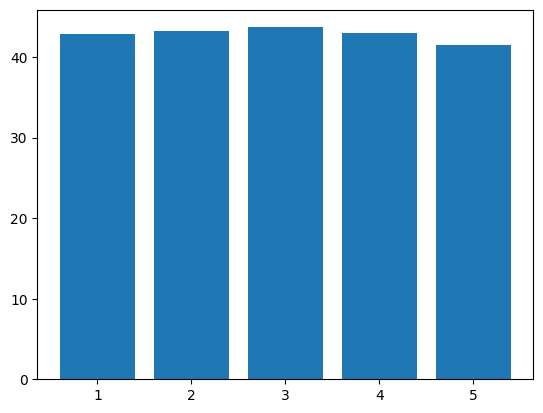

In [9]:
import matplotlib.pyplot as plt
plt.bar([1,2,3,4,5],df[df["time"]=="12:00:00"]["temp_d"])